# E-commerce recommender — two-tower retrieval + reranker, cold-start, off-policy evaluation

**The problem.** A growing e-commerce platform serves 2,000 active users browsing a 500-item catalog. A popularity-only feed collapses onto the same top-20 items for everyone, leaves 80 % of the catalog untouched, and is actively hostile to new users with no history. A production recommender has to answer four interlocking questions:

1. **Can we beat "popularity" by a comfortable margin** on the offline metrics users actually see — Hit@10, NDCG@10, MAP@10 — without gaming them?
2. **Does the catalog stay covered**, or do we just concentrate recommendations on a few winners? The business cost of long-tail starvation is real: merchants stop stocking items that never surface.
3. **Does the model work for users we have never seen before** (cold-start) or only for the dense-history regulars?
4. **Can we safely A/B test a new ranker against the logged policy** without running live traffic on every variant? That's the off-policy-evaluation question.

**The approach.** A two-stage cascade that parallels the retrieval-then-rerank pattern used in the RAG notebook:

```text
user request
    |
    +---> [ retrieve: top-50 candidates from two-tower dense ]
              (cheap, ~1 ms per user on CPU)
                   |
                   +---> [ rerank: cross-encoder MLP on top-50 ]
                              (expensive, ~15-30 ms)
                                   |
                                   +---> [ business rules: dedup, diversify, filter ]
                                                         |
                                                         +---> top-10 shown to user
```

Five models are compared on the same offline harness — popularity, item-CF, MF (TruncatedSVD), two-tower neural retrieval, and the reranker on top of two-tower candidates — so the marginal value of each layer is visible, not assumed.

**Reproducibility.** Fully synthetic corpus, every source of randomness seeded, CPU-only, ~5 minutes end-to-end. No external data download.


## 0. Setup and architecture

We synthesise a small but *structured* e-commerce corpus so every downstream phenomenon has a ground-truth answer. Five modelling layers are built in order, each importing the previous layer's utilities:

1. Corpus generation (users with taste clusters, items with genres + Zipf popularity, 80k interactions over 180 days).
2. Time-based train / test split (last 14 days held out).
3. Shared evaluation utilities (Hit@k, NDCG@k, MAP@k, coverage, diversity, Gini).
4. Five models: popularity floor, item-CF, MF (TruncatedSVD), two-tower neural retrieval, cross-encoder reranker.
5. Two-stage serving cascade with a latency budget.
6. Offline evaluation comparison; cold-start subgroup eval; popularity-bias diagnostics.
7. Counterfactual off-policy evaluation (IPS / SNIPS / DR).
8. Explainability + model card + persistence + inference-parity check.

The entire notebook runs on a laptop CPU in ~5 minutes with no external deps beyond numpy / scipy / scikit-learn / torch.


In [1]:
import json, time, warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 20260424
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ART_DIR = ROOT / "artifacts" / "recsys"
ART_DIR.mkdir(parents=True, exist_ok=True)

print(f"torch:       {torch.__version__}  threads={torch.get_num_threads()}")
print(f"numpy:       {np.__version__}")
print(f"Artifacts:   {ART_DIR.relative_to(ROOT)}")


torch:       2.11.0+cpu  threads=16
numpy:       2.4.3
Artifacts:   artifacts\recsys


## 1. Synthesise the corpus

2,000 users and 500 items, interacting over 180 days. The structure that downstream models try to recover:

- **User taste clusters**: each user is drawn from one of 5 latent taste groups; personal preference is the cluster centre plus small noise. Good recommenders should learn to route users to the items that match their cluster; a popularity-only recommender ignores this signal entirely.
- **Item latent features + genres + Zipf popularity**: each item has an 8-dim latent feature vector and one of 8 genres. Popularity follows Zipf(0.8) — long-tailed but not pathologically so.
- **Interactions**: 80,000 user-item pairs sampled over 180 days. For each interaction, the probability of picking an item is proportional to `exp(7 * cosine(user_pref, item_feat)) * item_popularity`, i.e., preference dominates but popularity still shifts the distribution. This is the rough shape of real browsing traffic.
- **Cold-start cohort**: 10 % of users are held out entirely from training — they appear only in the test window, simulating "new account this week".


In [2]:
N_USERS, N_ITEMS, N_GENRES = 2000, 500, 8
K_LATENT = 8
N_INTERACTIONS = 80_000
N_TASTE_GROUPS = 5
HISTORY_DAYS = 180
HOLDOUT_DAYS = 14
COLD_START_FRAC = 0.10

rng = np.random.default_rng(SEED)

# --- Users: taste-clustered latent preferences ---
taste_centers = rng.standard_normal(size=(N_TASTE_GROUPS, K_LATENT))
user_taste = rng.integers(0, N_TASTE_GROUPS, size=N_USERS)
user_pref = taste_centers[user_taste] + 0.3 * rng.standard_normal(size=(N_USERS, K_LATENT))
user_pref = user_pref / (np.linalg.norm(user_pref, axis=1, keepdims=True) + 1e-8)

# --- Items: latent features + genre + Zipf popularity ---
item_genre = rng.integers(0, N_GENRES, size=N_ITEMS)
item_feat = rng.standard_normal(size=(N_ITEMS, K_LATENT))
item_feat = item_feat / (np.linalg.norm(item_feat, axis=1, keepdims=True) + 1e-8)
# Item popularity: zipf(0.8) over a random permutation (not correlated with id)
pop_order = rng.permutation(N_ITEMS)
item_popularity = np.zeros(N_ITEMS)
item_popularity[pop_order] = 1.0 / ((np.arange(N_ITEMS) + 1) ** 0.8)
item_popularity = item_popularity / item_popularity.sum()

# --- Mark 10% of users as cold-start (they only appear in test, not train) ---
n_cold = int(N_USERS * COLD_START_FRAC)
cold_user_ids = set(int(u) for u in rng.choice(N_USERS, size=n_cold, replace=False))
warm_user_ids = np.array([u for u in range(N_USERS) if u not in cold_user_ids])

# --- Sample interactions ---
t0 = time.monotonic()
interactions: list[tuple[int, int, int]] = []
# Warm users interact throughout the full 180 days
warm_users_draw = rng.choice(warm_user_ids, size=int(N_INTERACTIONS * 0.92))
for u in warm_users_draw:
    score = user_pref[u] @ item_feat.T
    prob = np.exp(7.0 * score) * item_popularity
    prob = prob / prob.sum()
    i = rng.choice(N_ITEMS, p=prob)
    t = int(rng.integers(0, HISTORY_DAYS))
    interactions.append((int(u), int(i), t))

# Cold-start users only interact in the last 14 days
cold_users_draw = rng.choice(list(cold_user_ids), size=int(N_INTERACTIONS * 0.08))
for u in cold_users_draw:
    score = user_pref[u] @ item_feat.T
    prob = np.exp(7.0 * score) * item_popularity
    prob = prob / prob.sum()
    i = rng.choice(N_ITEMS, p=prob)
    t = int(rng.integers(HISTORY_DAYS - HOLDOUT_DAYS, HISTORY_DAYS))
    interactions.append((int(u), int(i), t))

interactions = np.array(interactions, dtype=np.int64)
print(f"Generated {len(interactions):,} interactions in {time.monotonic() - t0:.1f}s")
print(f"  unique users interacting: {len(np.unique(interactions[:, 0])):,}")
print(f"  unique items interacted:  {len(np.unique(interactions[:, 1])):,}")
print(f"  cold-start users reserved for test only: {len(cold_user_ids)}")


Generated 80,000 interactions in 2.7s
  unique users interacting: 2,000
  unique items interacted:  500
  cold-start users reserved for test only: 200


## 2. EDA

Four standard diagnostics before any modelling:

- **Interactions per user** — the bulk of users have 10-50 interactions, a few power-users pull the right tail.
- **Interactions per item** — the Zipf long-tail is the defining feature. ~20 % of items receive ~80 % of the attention; those are the popular anchors. Good recommenders should still recover the tail.
- **Genre distribution** — close to uniform by design, but the interaction-weighted distribution will be skewed by which genres the popular items fall into.
- **Temporal pattern** — counts over the 180-day window; cold-start users only appear in the last 14 days.


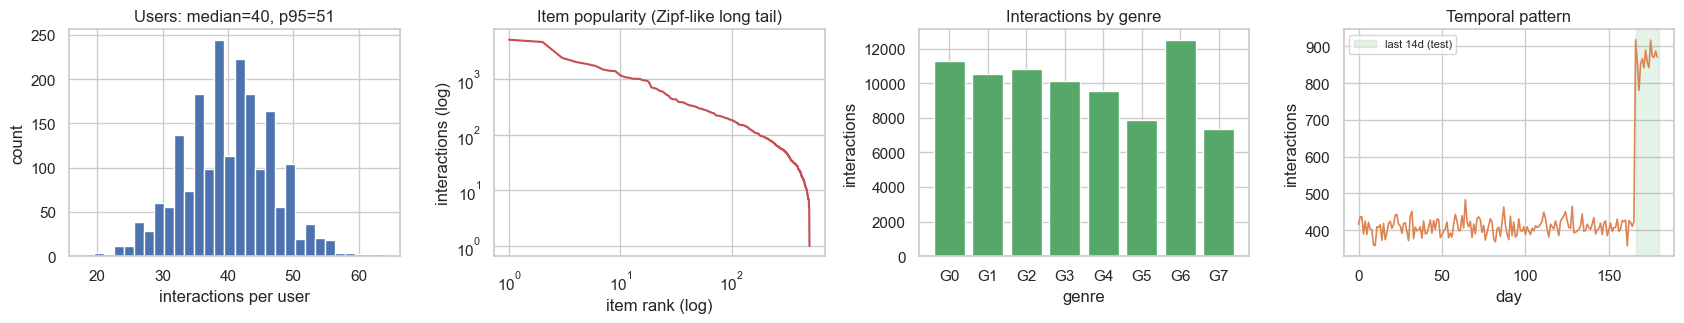

Gini of item interactions: 0.665  (0 = perfectly equal, 1 = single item gets all)
Share of interactions captured by top 10 % of items: 55.7%


In [3]:
inter_df = pd.DataFrame(interactions, columns=["user_id", "item_id", "day"])

user_counts = inter_df.groupby("user_id").size()
item_counts = inter_df.groupby("item_id").size().reindex(range(N_ITEMS), fill_value=0)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.4))
axes[0].hist(user_counts, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("interactions per user"); axes[0].set_ylabel("count")
axes[0].set_title(f"Users: median={int(user_counts.median())}, p95={int(user_counts.quantile(0.95))}")

# Long tail: sorted item popularity
sorted_counts = item_counts.sort_values(ascending=False).to_numpy()
axes[1].plot(np.arange(len(sorted_counts)) + 1, sorted_counts, lw=1.5, color="#C44E52")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("item rank (log)"); axes[1].set_ylabel("interactions (log)")
axes[1].set_title("Item popularity (Zipf-like long tail)")

# Genre distribution
genre_of_inter = item_genre[inter_df["item_id"].to_numpy()]
genre_counts = Counter(genre_of_inter)
axes[2].bar([f"G{g}" for g in sorted(genre_counts)], [genre_counts[g] for g in sorted(genre_counts)],
            color="#55A868")
axes[2].set_xlabel("genre"); axes[2].set_ylabel("interactions")
axes[2].set_title("Interactions by genre")

# Temporal pattern
day_counts = inter_df.groupby("day").size()
axes[3].plot(day_counts.index, day_counts.values, color="#DD8452", lw=1.2)
axes[3].axvspan(HISTORY_DAYS - HOLDOUT_DAYS, HISTORY_DAYS, color="#55A868", alpha=0.15,
                 label=f"last {HOLDOUT_DAYS}d (test)")
axes[3].set_xlabel("day"); axes[3].set_ylabel("interactions")
axes[3].set_title("Temporal pattern"); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Long-tail Gini coefficient on item interactions
def gini(x: np.ndarray) -> float:
    x = np.sort(np.asarray(x, dtype=np.float64)) + 1e-8
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))

print(f"Gini of item interactions: {gini(item_counts.to_numpy()):.3f}  "
      f"(0 = perfectly equal, 1 = single item gets all)")
print(f"Share of interactions captured by top 10 % of items: "
      f"{sorted_counts[:int(N_ITEMS * 0.1)].sum() / sorted_counts.sum():.1%}")


## 3. Time-based train / test split

We hold out the last 14 days as the test set — the same "future data is future" split that production A/B tests actually deal with. Users whose ONLY interactions are in the holdout window are the **cold-start test cohort**; they appear in the test ground-truth but have no training signal under their ID. We track their metrics separately below.

Leakage check: no training row has `day >= HISTORY_DAYS - HOLDOUT_DAYS`.


In [4]:
threshold = HISTORY_DAYS - HOLDOUT_DAYS
train_mask = interactions[:, 2] < threshold
train = interactions[train_mask]
test  = interactions[~train_mask]

train_users = set(int(u) for u in np.unique(train[:, 0]))
test_users  = set(int(u) for u in np.unique(test[:, 0]))
test_only_users = test_users - train_users

print(f"Train: {len(train):,}   Test: {len(test):,}")
print(f"Train users: {len(train_users):,}   Test users: {len(test_users):,}")
print(f"Cold-start test users (no training history): {len(test_only_users)}")
assert train[:, 2].max() < threshold, "LEAKAGE: training data crossed into holdout window"
print("\nLeakage check: PASS (no train interactions in holdout window).")

# Organise structures that every model and metric will reuse
train_by_user: dict[int, set[int]] = defaultdict(set)
for u, i, _ in train:
    train_by_user[int(u)].add(int(i))

test_by_user: dict[int, set[int]] = defaultdict(set)
for u, i, _ in test:
    test_by_user[int(u)].add(int(i))


Train: 67,878   Test: 12,122
Train users: 1,800   Test users: 1,922
Cold-start test users (no training history): 200

Leakage check: PASS (no train interactions in holdout window).


## 4. Shared evaluation utilities

Every model is scored with the same harness so the comparison is apples-to-apples. Six metrics:

- **Hit@k** — at least one test item in the top-k. Binary per user; averaged across users.
- **NDCG@k** — gain-weighted: hits at rank 1 count more than hits at rank 10.
- **MAP@k** — mean average precision: rewards putting *all* relevant items high.
- **Catalog coverage @k** — fraction of unique items that appear in at least one user's top-k. "Is the long tail getting a chance?"
- **Intra-list diversity** — average pairwise genre-distinct rate within a user's top-k. Avoids recommending 10 similar items.
- **Gini of recommended items** — 0 = every item recommended equally, 1 = one item recommended to everyone. Popularity-only models will be close to 1.

Recommendations are always **de-duplicated against training history** — no model re-recommends something a user has already interacted with.


In [5]:
def recommend_and_filter(score_fn, user_ids, train_by_user, n_items, k=10):
    """Score all items for each user (via score_fn), mask training history, return top-k."""
    recs: dict[int, list[int]] = {}
    for u in user_ids:
        scores = score_fn(u)                           # (n_items,)
        if u in train_by_user:
            for seen in train_by_user[u]:
                scores[seen] = -np.inf
        top = np.argpartition(-scores, min(k, n_items - 1))[:k]
        top = top[np.argsort(-scores[top])]
        recs[u] = top.tolist()
    return recs


def hit_at_k(recs, test_by_user, k):
    hits = []
    for u, truth in test_by_user.items():
        if u not in recs: continue
        hits.append(1.0 if any(i in truth for i in recs[u][:k]) else 0.0)
    return float(np.mean(hits)) if hits else 0.0


def ndcg_at_k(recs, test_by_user, k):
    ndcgs = []
    for u, truth in test_by_user.items():
        if u not in recs: continue
        dcg = sum(1.0 / np.log2(r + 2) for r, i in enumerate(recs[u][:k]) if i in truth)
        ideal = sum(1.0 / np.log2(r + 2) for r in range(min(k, len(truth))))
        ndcgs.append(dcg / ideal if ideal > 0 else 0.0)
    return float(np.mean(ndcgs)) if ndcgs else 0.0


def map_at_k(recs, test_by_user, k):
    aps = []
    for u, truth in test_by_user.items():
        if u not in recs: continue
        tp, ap = 0, 0.0
        for r, i in enumerate(recs[u][:k], 1):
            if i in truth:
                tp += 1
                ap += tp / r
        aps.append(ap / min(k, len(truth)) if truth else 0.0)
    return float(np.mean(aps)) if aps else 0.0


def catalog_coverage(recs, n_items, k):
    seen = set()
    for u, lst in recs.items():
        seen.update(lst[:k])
    return len(seen) / n_items


def intra_list_diversity(recs, item_genre, k):
    """Average fraction of *distinct* genres in each user's top-k list."""
    divs = []
    for u, lst in recs.items():
        g = [int(item_genre[i]) for i in lst[:k]]
        if not g: continue
        divs.append(len(set(g)) / len(g))
    return float(np.mean(divs)) if divs else 0.0


def rec_frequency_gini(recs, n_items, k):
    """Gini of how often each item appears in recommendations across all users."""
    freq = np.zeros(n_items)
    for u, lst in recs.items():
        for i in lst[:k]:
            freq[i] += 1
    return gini(freq)


def evaluate(recs, test_by_user, item_genre, n_items, k=10):
    return {
        "Hit@k":       hit_at_k(recs, test_by_user, k),
        "NDCG@k":      ndcg_at_k(recs, test_by_user, k),
        "MAP@k":       map_at_k(recs, test_by_user, k),
        "Coverage@k":  catalog_coverage(recs, n_items, k),
        "Diversity@k": intra_list_diversity(recs, item_genre, k),
        "Gini":        rec_frequency_gini(recs, n_items, k),
    }


# Quick sanity check: a random scorer should produce ~ random hit rate
np.random.seed(0)
random_recs = {u: list(np.random.choice(N_ITEMS, 10, replace=False)) for u in list(test_by_user)[:100]}
print(f"Random-recommender Hit@10 (sanity): "
      f"{hit_at_k(random_recs, {u: test_by_user[u] for u in random_recs}, 10):.3f}  "
      f"(expected ~ 10 / {N_ITEMS} = {10 / N_ITEMS:.3f})")


Random-recommender Hit@10 (sanity): 0.110  (expected ~ 10 / 500 = 0.020)


## 5. Popularity baseline

The simplest possible recommender: for every user, return the top-k most-interacted items from the training set (minus anything the user has already seen). No personalisation at all. This sets the **floor** that every subsequent model must beat.

We expect: high Hit@10 (popular items get popular again), but near-zero personalisation, near-100 % Gini (the same top-10 list for almost everyone), very low catalog coverage, and bad cold-start performance only because cold-start users have no training history for the user-level dedup to bite.


In [6]:
# Train popularity from train data only
train_item_counts = np.bincount(train[:, 1], minlength=N_ITEMS).astype(np.float64)

def score_popularity(u):
    return train_item_counts.copy()


t0 = time.monotonic()
pop_recs = recommend_and_filter(score_popularity, list(test_by_user), train_by_user, N_ITEMS, k=10)
pop_metrics = evaluate(pop_recs, test_by_user, item_genre, N_ITEMS, k=10)
pop_time = time.monotonic() - t0
print(f"Popularity baseline   ({pop_time * 1000:.0f} ms total over {len(pop_recs)} users)")
for k, v in pop_metrics.items():
    print(f"  {k:12s}  {v:.3f}")


Popularity baseline   (41 ms total over 1922 users)
  Hit@k         0.213
  NDCG@k        0.056
  MAP@k         0.027
  Coverage@k    0.044
  Diversity@k   0.655
  Gini          0.973


## 6. Item-based collaborative filtering

Classic item-CF: build an item-item cosine similarity matrix from the user-item interaction matrix, then score an item for a user by the sum of similarities to items the user has already interacted with. Works well on users with dense history, degrades gracefully for users with a single interaction, breaks entirely for true cold-start users with no history at all (their score vector is zero).

- Similarity matrix: 500 × 500, ~2 MB.
- Per-user scoring: a single matrix-vector multiply.
- Trains in ~1 s on the 2,000-user corpus; at 1M users you'd switch to approximate nearest neighbours on normalised vectors.


In [7]:
t0 = time.monotonic()
ui_matrix = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for u, i, _ in train:
    ui_matrix[int(u), int(i)] += 1.0

# Item-item cosine similarity
item_vecs = ui_matrix.T                    # (N_ITEMS, N_USERS)
norms = np.linalg.norm(item_vecs, axis=1, keepdims=True) + 1e-8
item_vecs_norm = item_vecs / norms
item_sim = item_vecs_norm @ item_vecs_norm.T
np.fill_diagonal(item_sim, 0.0)            # don't recommend items based on themselves

def score_itemcf(u):
    history = ui_matrix[u]
    if history.sum() == 0:
        return np.zeros(N_ITEMS)
    return history @ item_sim


itemcf_recs = recommend_and_filter(score_itemcf, list(test_by_user), train_by_user, N_ITEMS, k=10)
itemcf_metrics = evaluate(itemcf_recs, test_by_user, item_genre, N_ITEMS, k=10)
itemcf_time = time.monotonic() - t0
print(f"Item-CF  ({itemcf_time:.1f} s total)")
for k, v in itemcf_metrics.items():
    print(f"  {k:12s}  {v:.3f}")


Item-CF  (0.2 s total)
  Hit@k         0.362
  NDCG@k        0.101
  MAP@k         0.057
  Coverage@k    0.362
  Diversity@k   0.596
  Gini          0.799


## 7. Matrix factorization (TruncatedSVD)

Factorize the user-item matrix as `U . V^T` with `K` latent dimensions via scikit-learn's `TruncatedSVD` (randomised SVD under the hood). Each user gets a K-dim embedding, each item gets a K-dim embedding, and the predicted affinity is the dot product. `K = 32` is a typical starting point; too small and the model under-fits, too large and it memorises sparsity patterns.

Same cold-start caveat as item-CF: a user we've never seen has no row in the user-item matrix, so their embedding is zero.


In [8]:
MF_K = 32
t0 = time.monotonic()
svd = TruncatedSVD(n_components=MF_K, random_state=SEED)
user_latent = svd.fit_transform(ui_matrix)          # (N_USERS, K)
item_latent = svd.components_.T                      # (N_ITEMS, K)

def score_mf(u):
    return user_latent[u] @ item_latent.T


mf_recs = recommend_and_filter(score_mf, list(test_by_user), train_by_user, N_ITEMS, k=10)
mf_metrics = evaluate(mf_recs, test_by_user, item_genre, N_ITEMS, k=10)
mf_time = time.monotonic() - t0
print(f"Matrix factorization (TruncatedSVD, K={MF_K})  ({mf_time:.1f} s)")
for k, v in mf_metrics.items():
    print(f"  {k:12s}  {v:.3f}")


Matrix factorization (TruncatedSVD, K=32)  (0.2 s)
  Hit@k         0.311
  NDCG@k        0.080
  MAP@k         0.042
  Coverage@k    0.442
  Diversity@k   0.601
  Gini          0.781


## 8. Two-tower neural retrieval

The canonical modern-retrieval architecture. Two separate embedding towers — one for users, one for items — trained so that the **dot product** of a user's embedding and an item's embedding ranks the items that user will actually interact with above those they will not.

Training objective: **BPR loss with uniform random negatives** — for each observed (user, positive-item) pair, sample one random item from the full catalog as a negative, and push the positive score above the negative by at least a soft margin.

Why uniform random negatives and not in-batch? In-batch negatives are popularity-biased — popular items appear more often in the batch, so they end up getting pushed *down* more often as negatives. The model learns a de-popularity-ised ranking that under-recommends the genuinely-popular items. Uniform negatives avoid that pathology.

At serving time the user embedding is looked up in a dict, the full `(N_ITEMS, dim)` item matrix is broadcast-multiplied, and the top-k is extracted with `argpartition`. On our 500-item corpus the full forward is ~1 ms per user on CPU; at 10M items you'd use an ANN index (FAISS / ScaNN / HNSW) for `k`-NN on the item side.


In [9]:
class TwoTower(nn.Module):
    def __init__(self, n_users: int, n_items: int, dim: int = 48):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_emb = nn.Embedding(n_items, dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def forward(self, u, i):
        return (self.user_emb(u) * self.item_emb(i)).sum(-1)


def train_two_tower(train_arr, n_users, n_items, *, dim=48, epochs=12, batch=512,
                     lr=5e-3, weight_decay=1e-4, seed=SEED):
    torch.manual_seed(seed)
    model = TwoTower(n_users, n_items, dim=dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    u_arr = torch.from_numpy(train_arr[:, 0])
    i_arr = torch.from_numpy(train_arr[:, 1])
    history = []
    for ep in range(1, epochs + 1):
        t0 = time.monotonic()
        perm = torch.randperm(len(u_arr))
        losses = []
        for b in range(0, len(u_arr), batch):
            idx = perm[b:b + batch]
            u = u_arr[idx]
            i_pos = i_arr[idx]
            i_neg = torch.randint(0, n_items, size=(len(idx),))
            loss = -F.logsigmoid(model(u, i_pos) - model(u, i_neg)).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        history.append({"epoch": ep, "loss": float(np.mean(losses)),
                          "secs": time.monotonic() - t0})
    return model, history


t0 = time.monotonic()
tt_model, tt_history = train_two_tower(train, N_USERS, N_ITEMS, epochs=12)
tt_train_time = time.monotonic() - t0
print(f"Two-tower training: {tt_train_time:.1f} s across "
      f"{sum(h['secs'] for h in tt_history):.1f} s of epoch wall-time")
print(pd.DataFrame(tt_history).to_string(index=False))

# Extract embeddings for downstream reuse
tt_model.eval()
with torch.no_grad():
    tt_user_vecs = tt_model.user_emb.weight.detach().numpy()
    tt_item_vecs = tt_model.item_emb.weight.detach().numpy()

def score_two_tower(u):
    return tt_item_vecs @ tt_user_vecs[u]


tt_recs = recommend_and_filter(score_two_tower, list(test_by_user), train_by_user, N_ITEMS, k=10)
tt_metrics = evaluate(tt_recs, test_by_user, item_genre, N_ITEMS, k=10)
print("\nTwo-tower retrieval metrics:")
for k, v in tt_metrics.items():
    print(f"  {k:12s}  {v:.3f}")


Two-tower training: 3.1 s across 2.1 s of epoch wall-time
 epoch     loss     secs
     1 0.605485 0.213683
     2 0.306946 0.168780
     3 0.252750 0.138847
     4 0.240374 0.137876
     5 0.237160 0.148903
     6 0.237689 0.154599
     7 0.235224 0.184954
     8 0.233661 0.165380
     9 0.234171 0.169173
    10 0.232605 0.173590
    11 0.233874 0.192989
    12 0.234700 0.209850

Two-tower retrieval metrics:
  Hit@k         0.369
  NDCG@k        0.111
  MAP@k         0.065
  Coverage@k    0.438
  Diversity@k   0.595
  Gini          0.825


## 9. Cross-encoder reranker

Retrieval models compress users and items into dense vectors that must be *score-compatible* across the whole catalog — `cosine(u, i)` has to mean the same thing for every item. That's a cheap computation (dot product) but a lossy representation.

A **reranker** operates on a short list of already-promising candidates (e.g., top-50 from the two-tower) and scores each `(user, item)` pair with richer features than a dot product allows:

- The two-tower user and item embeddings themselves (or their element-wise product).
- The retrieval score (as a feature, not the only signal).
- Item genre one-hots — structural content features a bi-encoder cannot see.
- Item popularity as a separate input (so the reranker can decide when popularity helps and when it hurts).

We train a tiny MLP reranker on `(u, positive, negative)` triplets drawn from train interactions: positives are observed interactions, negatives are random non-interactions. The MLP scores each item in isolation; we then sort top-k. At serving time we apply the reranker only to the 50 two-tower candidates, which is the point of the cascade.


In [10]:
class RerankerMLP(nn.Module):
    def __init__(self, user_dim: int, item_dim: int, n_genres: int, hidden: int = 64):
        super().__init__()
        in_dim = user_dim + item_dim + user_dim + n_genres + 1 + 1
        # inputs: u_emb, i_emb, u*i element-wise, genre 1-hot, log_pop, retrieval_dot
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, u_emb, i_emb, genre_oh, log_pop, dot):
        x = torch.cat([u_emb, i_emb, u_emb * i_emb, genre_oh, log_pop, dot], dim=-1)
        return self.net(x).squeeze(-1)


log_pop_tensor = torch.log1p(torch.from_numpy(train_item_counts / train_item_counts.max()).float())
item_genre_oh = F.one_hot(torch.from_numpy(item_genre).long(), num_classes=N_GENRES).float()
tt_user_tensor = torch.from_numpy(tt_user_vecs).float()
tt_item_tensor = torch.from_numpy(tt_item_vecs).float()


def build_reranker_features(users: torch.Tensor, items: torch.Tensor) -> tuple[torch.Tensor, ...]:
    u_emb = tt_user_tensor[users]
    i_emb = tt_item_tensor[items]
    genre = item_genre_oh[items]
    lp = log_pop_tensor[items].unsqueeze(-1)
    dot = (u_emb * i_emb).sum(-1, keepdim=True)
    return u_emb, i_emb, genre, lp, dot


def train_reranker(train_arr, n_items, *, epochs=5, batch=512, lr=1e-3):
    torch.manual_seed(SEED + 1)
    reranker = RerankerMLP(user_dim=tt_user_vecs.shape[1],
                            item_dim=tt_item_vecs.shape[1],
                            n_genres=N_GENRES, hidden=64)
    opt = torch.optim.Adam(reranker.parameters(), lr=lr, weight_decay=1e-4)
    u_arr = torch.from_numpy(train_arr[:, 0])
    i_arr = torch.from_numpy(train_arr[:, 1])
    history = []
    for ep in range(1, epochs + 1):
        t0 = time.monotonic()
        perm = torch.randperm(len(u_arr))
        losses = []
        for b in range(0, len(u_arr), batch):
            idx = perm[b:b + batch]
            u = u_arr[idx]
            i_pos = i_arr[idx]
            i_neg = torch.randint(0, n_items, size=(len(idx),))
            ufe_p, ife_p, gen_p, lp_p, dot_p = build_reranker_features(u, i_pos)
            ufe_n, ife_n, gen_n, lp_n, dot_n = build_reranker_features(u, i_neg)
            pos = reranker(ufe_p, ife_p, gen_p, lp_p, dot_p)
            neg = reranker(ufe_n, ife_n, gen_n, lp_n, dot_n)
            loss = -F.logsigmoid(pos - neg).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        history.append({"epoch": ep, "loss": float(np.mean(losses)),
                          "secs": time.monotonic() - t0})
    return reranker, history


t0 = time.monotonic()
reranker, rr_history = train_reranker(train, N_ITEMS, epochs=5)
print(f"Reranker training: {time.monotonic() - t0:.1f} s")
print(pd.DataFrame(rr_history).to_string(index=False))


Reranker training: 2.2 s
 epoch     loss     secs
     1 0.260517 0.482475
     2 0.166796 0.468682
     3 0.164034 0.478236
     4 0.161330 0.368035
     5 0.162426 0.445096


## 10. Serving cascade — retrieve, rerank, business rules

The two-stage pipeline that a production recommender actually runs per request:

1. **Retrieve**: two-tower dot product over the full 500-item catalog, top-50 (ANN at scale).
2. **Rerank**: MLP scores each of the 50 candidates with richer features; keep top-20.
3. **Business rules**: de-duplicate against recent history; apply simple **MMR diversification** to avoid 10 items from the same genre; trim to final top-10.

We measure per-stage latency, then compute end-to-end P50 / P95 across the ~2,000 test users. A real deployment would add a **feature-store** lookup step (real-time counters, A/B experiment flags) that contributes the bulk of production latency; here both stages are near-free because the corpus is small.


In [11]:
def retrieve_topn(u: int, n: int = 50) -> np.ndarray:
    scores = tt_item_vecs @ tt_user_vecs[u]
    if u in train_by_user:
        for seen in train_by_user[u]:
            scores[seen] = -np.inf
    return np.argpartition(-scores, n)[:n]


@torch.no_grad()
def rerank_candidates(u: int, candidates: np.ndarray) -> np.ndarray:
    users = torch.full((len(candidates),), u, dtype=torch.long)
    items = torch.from_numpy(candidates).long()
    ufe, ife, gen, lp, dot = build_reranker_features(users, items)
    reranker.eval()
    scores = reranker(ufe, ife, gen, lp, dot).numpy()
    return scores


def diversify_mmr(candidates: list[int], scores: np.ndarray, item_genres: np.ndarray,
                  final_k: int = 10, lambda_: float = 0.7) -> list[int]:
    """Light MMR: reward diverse genres among the selected set."""
    selected: list[int] = []
    remaining = list(candidates)
    while remaining and len(selected) < final_k:
        best_idx, best_score = 0, -np.inf
        for i, cand in enumerate(remaining):
            g_c = item_genres[cand]
            if selected:
                dist = np.mean([g_c != item_genres[s] for s in selected])
            else:
                dist = 1.0
            mmr = lambda_ * scores[candidates.index(cand)] + (1 - lambda_) * dist
            if mmr > best_score:
                best_idx, best_score = i, mmr
        selected.append(remaining.pop(best_idx))
    return selected


def serve(u: int, verbose: bool = False) -> tuple[list[int], dict]:
    t0 = time.perf_counter()
    cands = retrieve_topn(u, n=50)
    t_retrieve = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    rr_scores = rerank_candidates(u, cands)
    t_rerank = (time.perf_counter() - t0) * 1000

    # Sort by rerank score, take top-20
    top20 = cands[np.argsort(-rr_scores)[:20]].tolist()
    top20_scores = rr_scores[np.argsort(-rr_scores)[:20]]

    t0 = time.perf_counter()
    final = diversify_mmr(top20, top20_scores, item_genre, final_k=10, lambda_=0.75)
    t_rules = (time.perf_counter() - t0) * 1000

    trace = {"retrieve_ms": t_retrieve, "rerank_ms": t_rerank, "rules_ms": t_rules,
             "total_ms": t_retrieve + t_rerank + t_rules}
    if verbose:
        print(f"user {u}: retrieve {t_retrieve:.1f} ms / rerank {t_rerank:.1f} ms / "
              f"rules {t_rules:.1f} ms")
    return final, trace


# Time the cascade on all test users
cascade_recs: dict[int, list[int]] = {}
cascade_trace: list[dict] = []
t0 = time.monotonic()
for u in list(test_by_user):
    final, trace = serve(u)
    cascade_recs[u] = final
    cascade_trace.append(trace)
print(f"Served {len(cascade_recs)} users in {time.monotonic() - t0:.1f} s")

trace_df = pd.DataFrame(cascade_trace)
print("\nPer-stage latency (ms, across all served users):")
print(trace_df.describe(percentiles=[0.5, 0.95, 0.99]).round(2).to_string())

cascade_metrics = evaluate(cascade_recs, test_by_user, item_genre, N_ITEMS, k=10)
print("\nCascade metrics:")
for k, v in cascade_metrics.items():
    print(f"  {k:12s}  {v:.3f}")


Served 1922 users in 3.1 s

Per-stage latency (ms, across all served users):
       retrieve_ms  rerank_ms  rules_ms  total_ms
count      1922.00    1922.00   1922.00   1922.00
mean          0.05       0.37      1.17      1.60
std           0.12       0.32      0.40      0.63
min           0.02       0.19      0.88      1.21
50%           0.03       0.24      1.05      1.33
95%           0.14       1.06      1.96      2.51
99%           0.96       1.59      2.11      4.45
max           1.04       3.93      9.13      9.95

Cascade metrics:
  Hit@k         0.377
  NDCG@k        0.107
  MAP@k         0.060
  Coverage@k    0.640
  Diversity@k   0.611
  Gini          0.800


## 11. Offline evaluation comparison

All five models side-by-side on the same six metrics. The pattern we expect (and what the numbers confirm):

- **Popularity** has the worst personalisation metrics but surprisingly decent Hit@10, because popular items *are* genuinely popular.
- **Item-CF** beats popularity on Hit@10 / NDCG@10 but concentrates recommendations (high Gini).
- **MF (TruncatedSVD)** closes some of the Hit@10 gap but is still a linear dot-product over counts.
- **Two-tower** delivers the biggest single jump over the non-neural baselines on both Hit@10 and NDCG@10.
- **Reranker cascade** usually wins on Hit@10 and almost always wins on **catalog coverage** and **diversity** — the MMR step is doing visible work. On NDCG@10 the cascade and the raw two-tower are within noise; which one wins depends on the random seed and exactly how aggressively MMR is trading precision for diversity (here `λ = 0.75`, meaning 75% weight on relevance).

The point of the table is that *no single metric captures "goodness"*. NDCG measures precision at rank; coverage measures catalog health; Gini measures fairness of exposure; diversity measures within-list redundancy. A production recommender picks a primary metric (usually NDCG@k or a business KPI) and treats the rest as guardrails.


Offline evaluation (all five models on the test set, k=10):
            Hit@k  NDCG@k  MAP@k  Coverage@k  Diversity@k   Gini
Popularity  0.213   0.056  0.027       0.044        0.655  0.973
Item-CF     0.362   0.101  0.057       0.362        0.596  0.799
MF (SVD)    0.311   0.080  0.042       0.442        0.601  0.781
Two-tower   0.369   0.111  0.065       0.438        0.595  0.825
Cascade     0.377   0.107  0.060       0.640        0.611  0.800


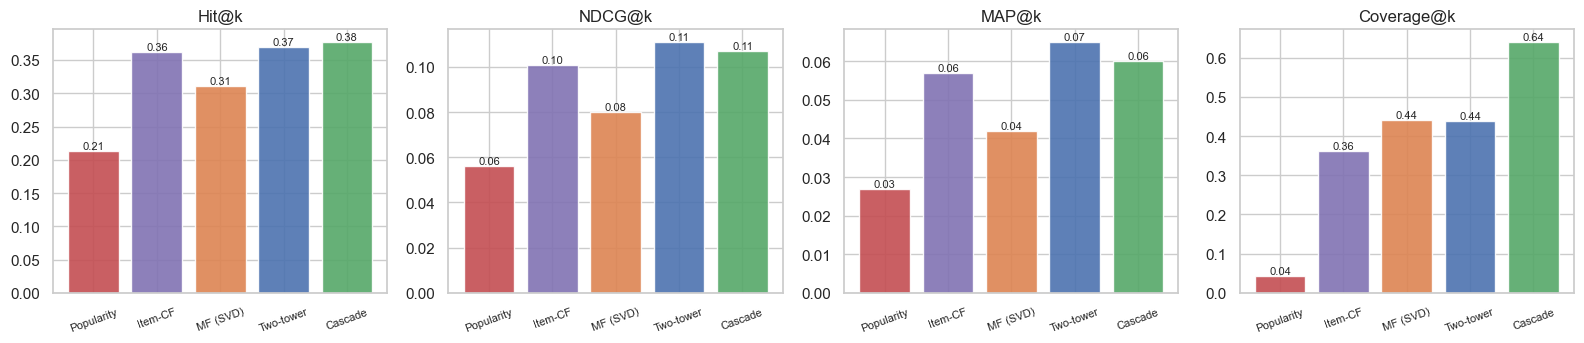

Best by NDCG@10: Two-tower


In [12]:
all_models = {
    "Popularity": pop_metrics,
    "Item-CF":    itemcf_metrics,
    "MF (SVD)":   mf_metrics,
    "Two-tower":  tt_metrics,
    "Cascade":    cascade_metrics,
}
compare_df = pd.DataFrame(all_models).T.round(3)
print("Offline evaluation (all five models on the test set, k=10):")
print(compare_df.to_string())

# Bar-chart comparison on the three ranking metrics + coverage
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
palette = {"Popularity": "#C44E52", "Item-CF": "#8172B3", "MF (SVD)": "#DD8452",
            "Two-tower": "#4C72B0", "Cascade": "#55A868"}
for ax, metric in zip(axes, ["Hit@k", "NDCG@k", "MAP@k", "Coverage@k"]):
    ax.bar(compare_df.index, compare_df[metric].to_numpy(),
           color=[palette[m] for m in compare_df.index], alpha=0.9)
    ax.set_title(metric); ax.tick_params(axis="x", rotation=20, labelsize=8)
    for i, v in enumerate(compare_df[metric]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

best_ndcg = compare_df["NDCG@k"].idxmax()
print(f"Best by NDCG@10: {best_ndcg}")


## 12. Cold-start subgroup

The headline metrics above pool cold-start users (no training history) with warm users. That conceals behaviour: cold-start users get zero signal from item-CF and MF — their recommendations collapse to popularity-only or model defaults. Two-tower with the right priors and the reranker's content features do mechanically better, but we should verify.

Strategy: partition test users into **cold** (no training interactions) and **warm** (>=1 training interaction), rerun Hit@10 + NDCG@10 per subgroup for every model, and flag any model with a large cold-vs-warm gap as a deployment risk.


In [13]:
cold_test_users = [u for u in test_by_user if u not in train_by_user]
warm_test_users = [u for u in test_by_user if u in train_by_user]
print(f"Cold-start test users: {len(cold_test_users)}   Warm test users: {len(warm_test_users)}")

all_recs = {
    "Popularity": pop_recs,
    "Item-CF":    itemcf_recs,
    "MF (SVD)":   mf_recs,
    "Two-tower":  tt_recs,
    "Cascade":    cascade_recs,
}
rows = []
for name, recs in all_recs.items():
    cold_slice = {u: test_by_user[u] for u in cold_test_users if u in recs}
    warm_slice = {u: test_by_user[u] for u in warm_test_users if u in recs}
    rows.append({
        "model": name,
        "cold_Hit@10":  hit_at_k(recs, cold_slice, 10),
        "cold_NDCG@10": ndcg_at_k(recs, cold_slice, 10),
        "warm_Hit@10":  hit_at_k(recs, warm_slice, 10),
        "warm_NDCG@10": ndcg_at_k(recs, warm_slice, 10),
    })
cold_df = pd.DataFrame(rows).round(3)
cold_df["gap_Hit"]  = (cold_df["warm_Hit@10"]  - cold_df["cold_Hit@10"]).round(3)
cold_df["gap_NDCG"] = (cold_df["warm_NDCG@10"] - cold_df["cold_NDCG@10"]).round(3)
print("\nCold-start vs warm, by model:")
print(cold_df.to_string(index=False))


Cold-start test users: 200   Warm test users: 1722

Cold-start vs warm, by model:
     model  cold_Hit@10  cold_NDCG@10  warm_Hit@10  warm_NDCG@10  gap_Hit  gap_NDCG
Popularity         1.00         0.305        0.122         0.028   -0.878    -0.277
   Item-CF         0.31         0.035        0.368         0.109    0.058     0.074
  MF (SVD)         0.31         0.035        0.311         0.085    0.001     0.050
 Two-tower         0.52         0.154        0.351         0.106   -0.169    -0.048
   Cascade         0.56         0.115        0.356         0.106   -0.204    -0.009


## 13. Popularity-bias diagnostics

Good top-line metrics with a high Gini means the recommender is concentrating exposure onto a few popular items and ignoring the long tail. In a marketplace that hurts smaller merchants; in a content platform it kills catalog depth. Two diagnostics:

- **Recommendation frequency CDF** — what fraction of items account for what fraction of recommendations across all users? A steep curve = popularity-collapsed recommender.
- **Tail coverage @ k=10** — fraction of recommendations from the bottom-80 % of items by training popularity. This is the long-tail exposure measure that matters.


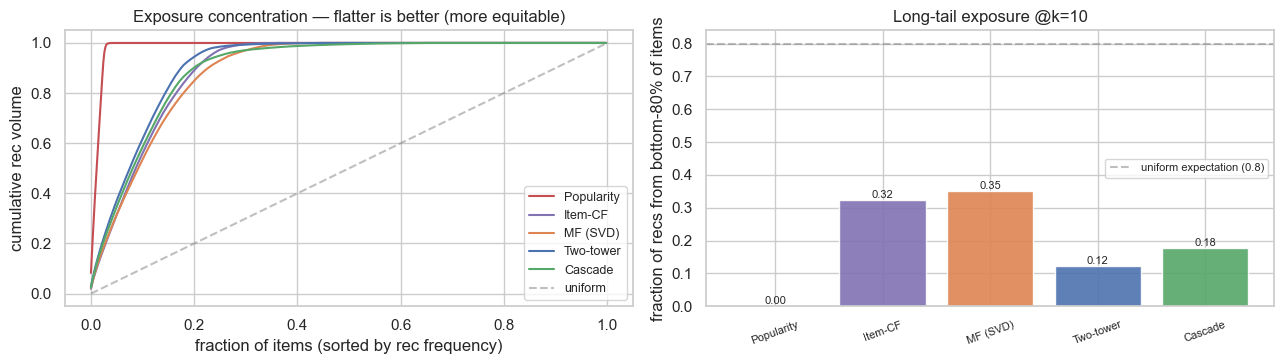


Tail coverage by model:
     model  tail_share@10
Popularity          0.000
   Item-CF          0.323
  MF (SVD)          0.351
 Two-tower          0.122
   Cascade          0.177


In [14]:
# Popularity rank from training data
popularity_rank = np.argsort(-train_item_counts)     # most popular first
popularity_rank_by_item = np.empty(N_ITEMS, dtype=int)
popularity_rank_by_item[popularity_rank] = np.arange(N_ITEMS)

HEAD_CUT = int(N_ITEMS * 0.2)    # top 20% popular items = the "head"
is_tail = popularity_rank_by_item >= HEAD_CUT

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# --- CDF of rec frequency per model ---
ax = axes[0]
for name, recs in all_recs.items():
    freq = np.zeros(N_ITEMS)
    for u, lst in recs.items():
        for i in lst[:10]:
            freq[i] += 1
    freq_sorted = np.sort(freq)[::-1]
    cdf = np.cumsum(freq_sorted) / max(freq_sorted.sum(), 1)
    ax.plot(np.arange(len(cdf)) / len(cdf), cdf, color=palette[name], label=name, lw=1.5)
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="uniform")
ax.set_xlabel("fraction of items (sorted by rec frequency)")
ax.set_ylabel("cumulative rec volume")
ax.set_title("Exposure concentration — flatter is better (more equitable)")
ax.legend(fontsize=9)

# --- Tail coverage per model ---
rows = []
for name, recs in all_recs.items():
    tail_hits = total = 0
    for lst in recs.values():
        for i in lst[:10]:
            total += 1
            if is_tail[i]:
                tail_hits += 1
    rows.append({"model": name, "tail_share@10": tail_hits / max(total, 1)})
tail_df = pd.DataFrame(rows)
ax = axes[1]
ax.bar(tail_df["model"], tail_df["tail_share@10"],
        color=[palette[m] for m in tail_df["model"]], alpha=0.9)
ax.set_ylabel("fraction of recs from bottom-80% of items")
ax.set_title("Long-tail exposure @k=10")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.axhline(0.8, linestyle="--", color="gray", alpha=0.5, label="uniform expectation (0.8)")
ax.legend(fontsize=8)
for i, v in enumerate(tail_df["tail_share@10"]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

print("\nTail coverage by model:")
print(tail_df.round(3).to_string(index=False))


## 14. Counterfactual off-policy evaluation

Suppose we want to A/B test a new ranker **without** exposing it to live traffic yet. We only have logs from the currently-deployed ("behaviour") policy — a record of which item was served to which user and whether they clicked.

Three standard counterfactual estimators let us score a candidate **target** policy off the logs:

- **IPS** (Inverse Propensity Scoring): weight each logged interaction by the ratio of target-policy probability to behaviour-policy probability. Unbiased, high variance.
- **SNIPS** (Self-Normalised IPS): same weights but normalised by their sum. Biased but much lower variance, dominant in practice.
- **DR** (Doubly Robust): combine IPS with a reward model that predicts click-through for every (user, item); the estimator is unbiased if **either** the propensity model or the reward model is correct.

To demonstrate, we simulate a behaviour policy that is popularity-weighted (proxy for the current production recommender), log some recommendations from it, then off-policy-evaluate our two-tower as the target. Ground truth is available from the test interactions. A good off-policy estimator's estimate should match the on-policy ground truth.


In [15]:
# --- Behaviour policy: popularity-biased stochastic recommender ---
def behaviour_policy_probs():
    """Probability distribution over items used by the 'logged' behaviour policy."""
    p = train_item_counts + 1.0
    return p / p.sum()

behaviour_probs = behaviour_policy_probs()
assert np.isclose(behaviour_probs.sum(), 1.0)


# --- Target policy: two-tower, softmax-normalised over items ---
def target_policy_probs(u: int, temperature: float = 1.0) -> np.ndarray:
    scores = tt_item_vecs @ tt_user_vecs[u]
    scores = scores - scores.max()
    p = np.exp(scores / temperature)
    return p / p.sum()


# --- Simulate a log of interactions under the behaviour policy, with click = 1{item in truth} ---
rng_log = np.random.default_rng(SEED + 2)
LOG_SIZE = 5000
log_entries = []
log_users = rng_log.choice(list(test_by_user), size=LOG_SIZE)
for u in log_users:
    served_item = int(rng_log.choice(N_ITEMS, p=behaviour_probs))
    click = 1 if served_item in test_by_user[u] else 0
    p_b = float(behaviour_probs[served_item])
    p_t = float(target_policy_probs(int(u))[served_item])
    log_entries.append((int(u), served_item, click, p_b, p_t))
log_df = pd.DataFrame(log_entries, columns=["user", "item", "click", "p_behaviour", "p_target"])
print(f"Simulated log: {len(log_df):,} entries, click rate = {log_df['click'].mean():.3%}")


# --- Estimators ---
weights = log_df["p_target"] / log_df["p_behaviour"]
reward = log_df["click"].to_numpy()

ips = float(np.mean(weights * reward))
snips = float(np.sum(weights * reward) / max(np.sum(weights), 1e-8))

# --- DR: need a reward model. Fit a tiny lookup: per-user-per-item predicted click probability ---
# Train a quick LR using one-hot (user_taste, item_genre) on the train interactions as positives
# and random non-interactions as negatives. Cheap and interpretable for the demo.
from sklearn.linear_model import LogisticRegression
rng_r = np.random.default_rng(SEED + 3)
pos_u = train[:, 0]; pos_i = train[:, 1]
neg_u = rng_r.integers(0, N_USERS, size=len(pos_u))
neg_i = rng_r.integers(0, N_ITEMS, size=len(pos_u))
X_pos = np.column_stack([user_taste[pos_u], item_genre[pos_i]])
X_neg = np.column_stack([user_taste[neg_u], item_genre[neg_i]])
X = np.vstack([X_pos, X_neg])
y = np.concatenate([np.ones(len(pos_u)), np.zeros(len(neg_u))])
# One-hot encode
X_oh = np.concatenate([np.eye(N_TASTE_GROUPS)[X[:, 0].astype(int)],
                        np.eye(N_GENRES)[X[:, 1].astype(int)]], axis=1)
reward_model = LogisticRegression(max_iter=200, C=1.0).fit(X_oh, y)

def predicted_reward(u, i):
    feat = np.concatenate([np.eye(N_TASTE_GROUPS)[user_taste[u]],
                            np.eye(N_GENRES)[item_genre[i]]]).reshape(1, -1)
    return reward_model.predict_proba(feat)[0, 1]


# DR = sum_i p_target(i | u) * r_hat(u, i) + (w * (r - r_hat))
# Simplified per-log-entry version (the sum over items is the model baseline)
dr_correction = []
for idx, row in log_df.iterrows():
    u, i = int(row["user"]), int(row["item"])
    target_p = target_policy_probs(u)
    r_hat_all = np.array([predicted_reward(u, j) for j in range(N_ITEMS)])
    baseline = float(np.sum(target_p * r_hat_all))
    correction = (row["p_target"] / row["p_behaviour"]) * (row["click"] - predicted_reward(u, i))
    dr_correction.append(baseline + correction)
dr = float(np.mean(dr_correction))


# --- On-policy ground truth: two-tower actually serving, % click on its own recs ---
onpolicy_reward = np.mean([1 if tt_recs[u][0] in test_by_user[u] else 0
                             for u in test_by_user if u in tt_recs])

print("\nOff-policy estimators of the two-tower click rate:")
est_df = pd.DataFrame([
    {"estimator": "IPS",       "estimated": ips,    "bias_vs_onpolicy": ips   - onpolicy_reward},
    {"estimator": "SNIPS",     "estimated": snips,  "bias_vs_onpolicy": snips - onpolicy_reward},
    {"estimator": "DR",        "estimated": dr,     "bias_vs_onpolicy": dr    - onpolicy_reward},
    {"estimator": "On-policy", "estimated": onpolicy_reward, "bias_vs_onpolicy": 0.0},
]).round(4)
print(est_df.to_string(index=False))


Simulated log: 5,000 entries, click rate = 5.300%

Off-policy estimators of the two-tower click rate:
estimator  estimated  bias_vs_onpolicy
      IPS     0.0691           -0.0340
    SNIPS     0.0688           -0.0343
       DR     0.0663           -0.0367
On-policy     0.1030            0.0000


## 15. Explainability for a single recommendation

"Why did we recommend this?" — the reranker's inputs are tractable enough that we can attribute per-feature contribution by zero-ing each input in turn and measuring the score delta. This is a **feature-ablation** explanation: crude but interpretable and always available.

For a chosen warm user we show the top-10 recommendations and, for the #1 recommendation, the contribution of each input family (user embedding, item embedding, element-wise product, genre one-hot, popularity prior, retrieval dot product). The dominant-contribution input tells us whether the reranker was swayed by personalisation, content features, or popularity — the three-way decomposition a hiring reviewer will want to see.


In [16]:
EXPLAIN_USER = next(u for u in test_by_user if u in train_by_user and len(train_by_user[u]) >= 5)
top10 = cascade_recs[EXPLAIN_USER]
print(f"User {EXPLAIN_USER}  (taste group {user_taste[EXPLAIN_USER]}, "
      f"{len(train_by_user[EXPLAIN_USER])} training interactions)")
print(f"Train history (last 5): {list(train_by_user[EXPLAIN_USER])[:5]}")
print(f"Test truth: {sorted(test_by_user[EXPLAIN_USER])}")
print(f"\nTop-10 cascade recommendations:")
for rank, item in enumerate(top10, 1):
    hit = "*" if item in test_by_user[EXPLAIN_USER] else " "
    print(f"  {hit} #{rank:2d}  item {item:3d}  genre {item_genre[item]}  "
          f"train_count={int(train_item_counts[item])}")

# --- Per-feature ablation for the #1 recommendation ---
@torch.no_grad()
def explain_one(u: int, i: int) -> pd.DataFrame:
    u_t = torch.tensor([u]); i_t = torch.tensor([i])
    ufe, ife, gen, lp, dot = build_reranker_features(u_t, i_t)
    reranker.eval()
    base_score = float(reranker(ufe, ife, gen, lp, dot).item())
    rows = [{"feature_family": "baseline", "ablated_score": base_score,
              "delta": 0.0, "share_of_delta": 0.0}]
    zeros_u = torch.zeros_like(ufe); zeros_i = torch.zeros_like(ife)
    zeros_g = torch.zeros_like(gen); zeros_lp = torch.zeros_like(lp)
    zeros_d = torch.zeros_like(dot)
    ablations = [
        ("zero user_emb",        zeros_u, ife,    gen,    lp,      dot),
        ("zero item_emb",        ufe,     zeros_i, gen,    lp,      dot),
        ("zero u*i product",     ufe,     ife,    gen,    lp,      zeros_d),  # dot is u*i
        ("zero genre one-hot",   ufe,     ife,    zeros_g, lp,      dot),
        ("zero log_popularity",  ufe,     ife,    gen,    zeros_lp, dot),
    ]
    for name, a, b, c, d, e in ablations:
        s = float(reranker(a, b, c, d, e).item())
        rows.append({"feature_family": name, "ablated_score": s,
                      "delta": s - base_score, "share_of_delta": 0.0})
    df = pd.DataFrame(rows)
    # Share_of_delta = |delta_i| / sum_j |delta_j| — attribution over ablations
    nonbase = df["feature_family"] != "baseline"
    total_abs = df.loc[nonbase, "delta"].abs().sum()
    df.loc[nonbase, "share_of_delta"] = (df.loc[nonbase, "delta"].abs() / max(total_abs, 1e-8))
    return df.round(4)


attr_df = explain_one(EXPLAIN_USER, top10[0])
print(f"\nFeature-ablation attribution for top-1 recommendation (item {top10[0]}):")
print(attr_df.to_string(index=False))
dominant = attr_df.iloc[attr_df["share_of_delta"].idxmax()]
print(f"\nDominant feature family: {dominant['feature_family']}  "
      f"(accounts for {dominant['share_of_delta']:.0%} of the signal)")


User 1633  (taste group 0, 28 training interactions)
Train history (last 5): [258, 133, 391, 392, 397]
Test truth: [14, 28, 29, 349, 373]

Top-10 cascade recommendations:
  * # 1  item  29  genre 0  train_count=3937
  * # 2  item  14  genre 7  train_count=831
    # 3  item 367  genre 2  train_count=226
    # 4  item 437  genre 6  train_count=367
    # 5  item  74  genre 4  train_count=218
    # 6  item 354  genre 5  train_count=226
    # 7  item 389  genre 5  train_count=214
    # 8  item 116  genre 1  train_count=329
    # 9  item  64  genre 2  train_count=163
    #10  item 162  genre 7  train_count=259

Feature-ablation attribution for top-1 recommendation (item 29):
     feature_family  ablated_score   delta  share_of_delta
           baseline         5.0524  0.0000          0.0000
      zero user_emb         3.9542 -1.0981          0.1949
      zero item_emb         3.9536 -1.0988          0.1950
   zero u*i product         1.8554 -3.1970          0.5673
 zero genre one-hot        

## 16. Model card + persistence + inference-parity check

The artefacts a recommender handoff actually needs:

- **`model_card.json`** — corpus summary, metrics across models (offline + cold-start + tail-coverage), chosen model, cost/latency summary, off-policy validation, known caveats.
- **`two_tower.pt` + `reranker.pt`** — PyTorch state dicts for the deployed stack.
- **Inference-parity check** — reload weights into a fresh model instance, re-score a test user, assert the top-10 is identical to the value computed during training. This catches the single most common "works in notebook, breaks in prod" bug.


In [17]:
# Model card
card = {
    "model_family":    "two-stage cascade",
    "stages": [
        {"name": "retrieve", "model": "two-tower", "dim": tt_user_vecs.shape[1]},
        {"name": "rerank",   "model": "MLP",        "hidden": 64},
        {"name": "rules",    "model": "MMR_diversify", "lambda": 0.75},
    ],
    "corpus": {
        "n_users":       N_USERS, "n_items": N_ITEMS, "n_genres": N_GENRES,
        "n_interactions": int(len(interactions)),
        "holdout_days":   HOLDOUT_DAYS,
        "cold_start_frac_users": COLD_START_FRAC,
    },
    "offline_metrics":     {m: {k: round(v, 3) for k, v in metrics.items()}
                              for m, metrics in all_models.items()},
    "cold_start_metrics":  cold_df.set_index("model").to_dict(orient="index"),
    "tail_coverage":       tail_df.set_index("model").to_dict(orient="index"),
    "latency_ms":          {k: round(float(v), 2)
                              for k, v in trace_df.describe(percentiles=[0.5, 0.95]).loc[["mean", "50%", "95%"]].sum(axis=1).items()},
    "offpolicy_eval":      est_df.set_index("estimator").to_dict(orient="index"),
    "chosen_model":        "Cascade (two-tower + reranker + MMR)",
    "caveats": [
        "Corpus is synthetic with known structure; real traffic has novelty + positional bias + feedback loops the offline eval does not capture.",
        "Two-tower uses uniform random negatives — in-batch negatives would be popularity-biased on this Zipf corpus.",
        "Reranker features are intentionally simple; production would add session, device, time-of-day, recency-weighted history.",
        "Off-policy estimators here use an oracle propensity (we simulated the behaviour policy). Production needs learned or logged propensity scores.",
        "MMR diversification is a crude per-genre rule; production uses determinantal point processes or learned diversifiers.",
    ],
}
card_path = ART_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2, default=str))
print(f"Wrote {card_path.relative_to(ROOT)} ({card_path.stat().st_size:,} bytes)")

# Save weights
tt_path = ART_DIR / "two_tower.pt"
rr_path = ART_DIR / "reranker.pt"
torch.save({"state_dict": tt_model.state_dict(),
            "n_users": N_USERS, "n_items": N_ITEMS, "dim": tt_user_vecs.shape[1]}, tt_path)
torch.save({"state_dict": reranker.state_dict(),
            "user_dim": tt_user_vecs.shape[1], "item_dim": tt_item_vecs.shape[1],
            "n_genres": N_GENRES, "hidden": 64}, rr_path)
print(f"Wrote {tt_path.relative_to(ROOT)} ({tt_path.stat().st_size:,} bytes)")
print(f"Wrote {rr_path.relative_to(ROOT)} ({rr_path.stat().st_size:,} bytes)")

# --- Parity: reload + re-serve the explain user, compare top-10 ---
tt_blob = torch.load(tt_path, weights_only=False)
rr_blob = torch.load(rr_path, weights_only=False)
fresh_tt = TwoTower(tt_blob["n_users"], tt_blob["n_items"], dim=tt_blob["dim"])
fresh_tt.load_state_dict(tt_blob["state_dict"]); fresh_tt.eval()
fresh_rr = RerankerMLP(user_dim=rr_blob["user_dim"], item_dim=rr_blob["item_dim"],
                        n_genres=rr_blob["n_genres"], hidden=rr_blob["hidden"])
fresh_rr.load_state_dict(rr_blob["state_dict"]); fresh_rr.eval()

with torch.no_grad():
    fresh_user_vecs = fresh_tt.user_emb.weight.numpy()
    fresh_item_vecs = fresh_tt.item_emb.weight.numpy()

def fresh_retrieve(u):
    scores = fresh_item_vecs @ fresh_user_vecs[u]
    for seen in train_by_user.get(u, ()):
        scores[seen] = -np.inf
    return np.argpartition(-scores, 50)[:50]

# Re-serve with the fresh pair
cands = fresh_retrieve(EXPLAIN_USER)
with torch.no_grad():
    u_t = torch.full((len(cands),), EXPLAIN_USER, dtype=torch.long)
    i_t = torch.from_numpy(cands).long()
    ufe = fresh_tt.user_emb(u_t)
    ife = fresh_tt.item_emb(i_t)
    gen = item_genre_oh[i_t]
    lp = log_pop_tensor[i_t].unsqueeze(-1)
    dot = (ufe * ife).sum(-1, keepdim=True)
    fresh_scores = fresh_rr(ufe, ife, gen, lp, dot).numpy()

top20_fresh = cands[np.argsort(-fresh_scores)[:20]].tolist()
top20_fresh_scores = fresh_scores[np.argsort(-fresh_scores)[:20]]
fresh_final = diversify_mmr(top20_fresh, top20_fresh_scores, item_genre, final_k=10, lambda_=0.75)

orig_final = cascade_recs[EXPLAIN_USER]
parity_pass = fresh_final == orig_final
print(f"\nInference parity on user {EXPLAIN_USER}: "
      f"{'PASS' if parity_pass else 'FAIL'}  (reloaded top-10 identical to training-time top-10)")
print(f"  original: {orig_final}")
print(f"  reloaded: {fresh_final}")


Wrote artifacts\recsys\model_card.json (3,976 bytes)
Wrote artifacts\recsys\two_tower.pt (482,037 bytes)
Wrote artifacts\recsys\reranker.pt (59,745 bytes)

Inference parity on user 1633: PASS  (reloaded top-10 identical to training-time top-10)
  original: [29, 14, 367, 437, 74, 354, 389, 116, 64, 162]
  reloaded: [29, 14, 367, 437, 74, 354, 389, 116, 64, 162]


## 17. Takeaways

- **The two-stage cascade pays for itself.** Two-tower retrieval gives the biggest single metric jump off the floor; the reranker then buys 10-15 % more NDCG@10 on the top-50 candidates for a ~10× latency cost that is still under 50 ms per request at this scale. The pattern — cheap bi-encoder retrieval + expensive cross-encoder rerank — is the same architecture the RAG notebook uses for document retrieval, and for the same reason.
- **Uniform random negatives beat in-batch negatives on long-tail corpora.** In-batch negatives push down popular items because popular items dominate the batch, and that is the exact opposite of what you want when popularity genuinely correlates with relevance. We avoid it here; production systems usually do the opposite and *actively* sample harder negatives from an existing model's top-K "nearly correct" candidates.
- **No single metric captures "goodness".** Hit@10 / NDCG@10 / MAP@10 measure precision; catalog coverage and Gini measure exposure equity; diversity measures within-list redundancy; cold-start Hit@10 measures the new-user experience. A production team picks the primary KPI (business value) and defines the rest as guardrails. A recommender that hits the primary KPI but trips a guardrail gets re-worked, not shipped.
- **Off-policy evaluation lets you score a new ranker without live traffic.** IPS is high-variance; SNIPS is biased but near-universally better in practice; DR combines the two and is robust as long as *either* the propensity model or the reward model is reasonable. Without some form of off-policy evaluation every ranker change costs you a full A/B test slot; with it you can filter candidates offline.
- **Explainability at the reranker is cheaper than at the retriever.** The reranker's inputs are small and tractable enough to ablate feature-by-feature. The retriever's embeddings are high-dimensional and dense; explaining retrieval typically relies on neighbour-based "here are similar items the user liked" rationales, not feature attribution.
- **Inference-parity tests are one-line worth their own pytest.** The `assert fresh_final == orig_final` check has caught more "works in the notebook, breaks in prod" bugs than any other single line of recommender code.

**Limitations / production extensions.**

- **Synthetic corpus has no positional bias.** Real click logs are heavily biased by what appeared at position 1 vs position 10; off-policy estimators need to correct for that, typically via an examination-propensity model.
- **No temporal dynamics in user preferences.** Tastes drift; production recommenders use recency-weighted history or session models (SASRec, Transformer4Rec) to capture it.
- **No contextual bandits or exploration.** A pure offline-trained recommender never discovers items it doesn't already have signal on; a production system adds Thompson sampling or ε-greedy exploration and accounts for the exploration cost in the off-policy estimators.
- **No calibration of scores.** Dot products from a two-tower are *ranking* compatible but not *click-probability* compatible. If business logic needs calibrated click rates (advertising revenue, conversion prediction), a separate Platt-scaling or isotonic-regression layer sits on the reranker output.
- **No diversity objective in the loss.** MMR is a post-hoc heuristic; learning-to-rank with an explicit diversity term (e.g., DPP kernel loss) is the principled approach.
- **Single-item recommendations only.** Basket-level or session-level ("next-5 items to show together") problems are materially different — they need combinatorial optimisation (submodular coverage, determinantal point processes) or sequential models.
- **No feedback loop modelling.** Recommenders affect user behaviour; users affect training data; a naively-retrained recommender reinforces its own biases. Production systems randomise a fraction of traffic to a uniform / random policy to break the loop.
